In [1]:
# Cell 1 — Imports & sanity check
import datasets
import transformers
import torch
import pandas as pd
import sklearn
import accelerate

print(f"datasets:     {datasets.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"torch:        {torch.__version__}")
print(f"accelerate:   {accelerate.__version__}")
print(f"Device:       {'mps' if torch.backends.mps.is_available() else 'cpu'}")

/Users/pragyansh/GitHub Projects/-hf-finetuning-distilbert/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets:     4.8.5
transformers: 5.9.0
torch:        2.12.0
accelerate:   1.13.0
Device:       mps


In [2]:
# Cell 2 — Load the emotion dataset
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

print(dataset)

Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 1261065.54 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [3]:
# Cell 3 — Explore labels and class distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()

# What do the label numbers mean?
print("Unique labels:", train_df["label"].unique())
print("Label distribution:\n", train_df["label"].value_counts().sort_index())

Unique labels: [0 3 2 5 4 1]
Label distribution:
 label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64


In [4]:
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


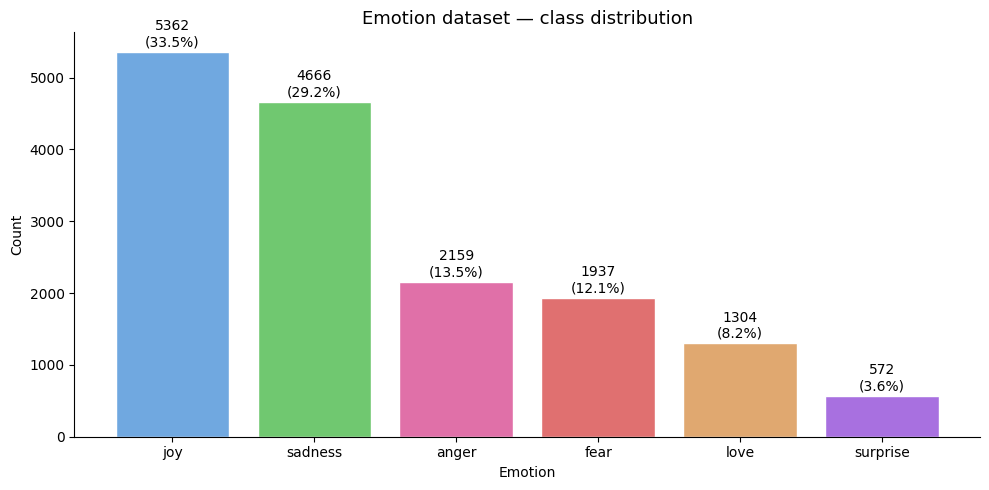

In [5]:
# Cell 4 — Class distribution visualisation
label_names = {0: "sadness", 1: "joy", 2: "love", 
               3: "anger", 4: "fear", 5: "surprise"}

train_df["emotion"] = train_df["label"].map(label_names)

fig, ax = plt.subplots(figsize=(10, 5))
counts = train_df["emotion"].value_counts()
colors = ["#70a8e0", "#70c870", "#e070a8", "#e07070", "#e0a870", "#a870e0"]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white")

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{count}\n({count/len(train_df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)

ax.set_title("Emotion dataset — class distribution", fontsize=13)
ax.set_xlabel("Emotion")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Cell 5 — Qualitative inspection
label_names = {0: "sadness", 1: "joy", 2: "love", 
               3: "anger", 4: "fear", 5: "surprise"}

for emotion_id, emotion_name in label_names.items():
    samples = train_df[train_df["label"] == emotion_id]["text"].sample(2, random_state=42)
    print(f"\n=== {emotion_name.upper()} ===")
    for s in samples:
        print(f"  → {s}")


=== SADNESS ===
  → im feeling so lousy they tried to cheer me up during school time and during choir practice
  → i feel highly disadvantaged

=== JOY ===
  → i feel im rather innocent in that respect
  → im feeling quite adventurous and tried out those drinks that i just normally read through the pages of pocketbooks

=== LOVE ===
  → i mean fuck i feel like i was way more considerate with customers and concerned about appearance and sanitiation snoozel pm but fine
  → i remember a couple of years ago i was feeling romantic and dreamy and asked him wonder if we ll celebrate our th anniversary

=== ANGER ===
  → i ve been feeling a bit cranky with the kids this week cranky baby whiny year old demanding preschooler so i wanted to stop and remember how blessed i really am
  → i feel frustrated sometimes with my mac lipsticks when i have to read names or open each of them to select shade

=== FEAR ===
  → i can feel the frantic beat of his heart but cookie s voice is surprisingly clear


In [7]:
# Cell 6 — Tokenisation (what pipeline() was hiding)
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenise a single example manually
sample_text = "i feel so happy today"
tokens = tokenizer(sample_text, return_tensors="pt")

print(f"Original text:  '{sample_text}'")
print(f"\nToken IDs:      {tokens['input_ids']}")
print(f"Attention mask: {tokens['attention_mask']}")
print(f"\nDecoded tokens: {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
print(f"\nVocabulary size: {tokenizer.vocab_size:,}")

Original text:  'i feel so happy today'

Token IDs:      tensor([[ 101, 1045, 2514, 2061, 3407, 2651,  102]])
Attention mask: tensor([[1, 1, 1, 1, 1, 1, 1]])

Decoded tokens: ['[CLS]', 'i', 'feel', 'so', 'happy', 'today', '[SEP]']

Vocabulary size: 30,522


In [8]:
# See subword tokenisation
unusual_words = ["unbelievable", "preprocessing", "Pragyansh"]
for word in unusual_words:
    tokens = tokenizer.tokenize(word)
    print(f"{word:20} → {tokens}")

unbelievable         → ['unbelievable']
preprocessing        → ['prep', '##ro', '##ces', '##sing']
Pragyansh            → ['pr', '##ag', '##yan', '##sh']


In [9]:
# Cell 7 — Tokenise the full dataset
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Apply tokenisation to entire dataset at once
tokenized_dataset = dataset.map(tokenize_function, batched=True)

print(tokenized_dataset)
print("\nFeatures after tokenisation:")
print(tokenized_dataset["train"].features)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 57259.34 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Features after tokenisation:
{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [10]:
# Cell 8 — Format for PyTorch
tokenized_dataset = tokenized_dataset.remove_columns(["text", "token_type_ids"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

print("Final dataset format:")
print(tokenized_dataset)
print("\nSample training example:")
print(tokenized_dataset["train"][0])

Final dataset format:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Sample training example:
{'labels': tensor(0), 'input_ids': tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0

In [11]:
# Cell 9 — Load DistilBERT for sequence classification
from transformers import AutoModelForSequenceClassification
import torch

num_labels = 6
label2id = {"sadness": 0, "joy": 1, "love": 2, 
            "anger": 3, "fear": 4, "surprise": 5}
id2label = {v: k for k, v in label2id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 23501.45it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     66,958,086
Trainable parameters: 66,958,086


In [14]:
# Cell 10 — Apply LoRA with PEFT
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                     # rank — size of the low-rank matrices
    lora_alpha=32,            # scaling factor
    lora_dropout=0.1,         # dropout for regularisation
    target_modules=["q_lin", "v_lin"]  # which layers to apply LoRA to
)

lora_model = get_peft_model(model, lora_config)

# Count parameters again
total_params = sum(p.numel() for p in lora_model.parameters())
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable %:          {trainable_params/total_params*100:.2f}%")
lora_model.print_trainable_parameters()

Total parameters:     67,700,748
Trainable parameters: 742,662
Trainable %:          1.10%
trainable params: 742,662 || all params: 67,700,748 || trainable%: 1.0970


In [13]:
pip install peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 14.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [15]:
# Cell 11 — Training configuration
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

print("Training configuration set.")
print(f"Epochs:     {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Steps/epoch:{16000 // training_args.per_device_train_batch_size}")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training configuration set.
Epochs:     3
Batch size: 16
Steps/epoch:1000


In [16]:
# Cell 12 — Evaluation metric
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    
    return {
        "accuracy": accuracy,
        "f1": f1
    }

print("Metrics function defined.")
print("Tracking: accuracy + weighted F1")

Metrics function defined.
Tracking: accuracy + weighted F1


In [ ]:
# Cell 13 — Build Trainer and train
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer ready. Starting training...")
trainer.train()

TypeError: Trainer.__init__() got an unexpected keyword argument 'tokenizer'